In [1]:
import deepchem as dc
import numpy as np
from sklearn.ensemble import RandomForestRegressor

tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='ECFP', splitter='random')
train_dataset, valid_dataset, test_dataset = datasets

rf = RandomForestRegressor(n_estimators=100)
rf.fit(train_dataset.X, train_dataset.y.ravel())

importances = rf.feature_importances_
top_bits = np.argsort(importances)[::-1][:10]
print("Top 10 most important fingerprint bits:", top_bits)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading material featurizer, missing a dependency. No module named 'ase'


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers.models.roberta.tokenization_roberta_fast'
cannot import name 'Chemberta' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/Users/sohanmulamalla/Desktop/Projects/soluscope-ai/venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


Top 10 most important fingerprint bits: [356 659 561 119 960 807 875 519  63 352]


In [3]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw

smiles = "CC(=O)OC1=CC=CC=C1C(=O)O" # aspirin
mol = Chem.MolFromSmiles(smiles)

bit_info = {}
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=bit_info)

active_important_bits = [b for b in top_bits if b in bit_info]
print("Important bits present in this molecule:", active_important_bits)

Important bits present in this molecule: [356, 807]


[16:28:21] DEPRECATION WARNING: please use MorganGenerator


In [8]:
if active_important_bits:
    bit_to_show = active_important_bits[0]
    img = Draw.DrawMorganBit(mol, bit_to_show, bit_info)
    img
else:
    print("None of the top bits are present in this molecule")

In [18]:
def explain_prediction(smiles, top_bits, n_show=3):
    mol = Chem.MolFromSmiles(smiles)
    bit_info = {}
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024, bitInfo=bit_info)
    active_bits = [b for b in top_bits if b in bit_info][:n_show]
    images = [Draw.DrawMorganBit(mol, b, bit_info) for b in active_bits]
    return images

images = explain_prediction("CCO", top_bits)

[17:00:17] DEPRECATION WARNING: please use MorganGenerator


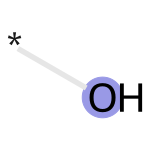

In [19]:
images[0]